In [53]:
from TdCARS2 import TdCARS
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
#import scienceplots
#plt.style.use(['science'])

In [54]:
root_dir = Path(r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS")

all_cars_files = [
    file for file in root_dir.rglob("*.dat")
    if "_notes" not in file.stem.lower()
    and "_spectra" not in file.stem.lower()
    and "_floor" not in file.stem.lower()
    and len(np.loadtxt(file)[0]) == 4
]

all_cars_files_with_spectra = [
    file for file in all_cars_files
    if (file.parent / f"{file.stem}_spectra.dat").exists()
]

print(f"Total files found: {len(all_cars_files)}")
print(f"Files with spectra: {len(all_cars_files_with_spectra)}")

Total files found: 365
Files with spectra: 188


[np.float64(859.1062949198525), np.float64(1978.5466466452233)] [-500, 2000]


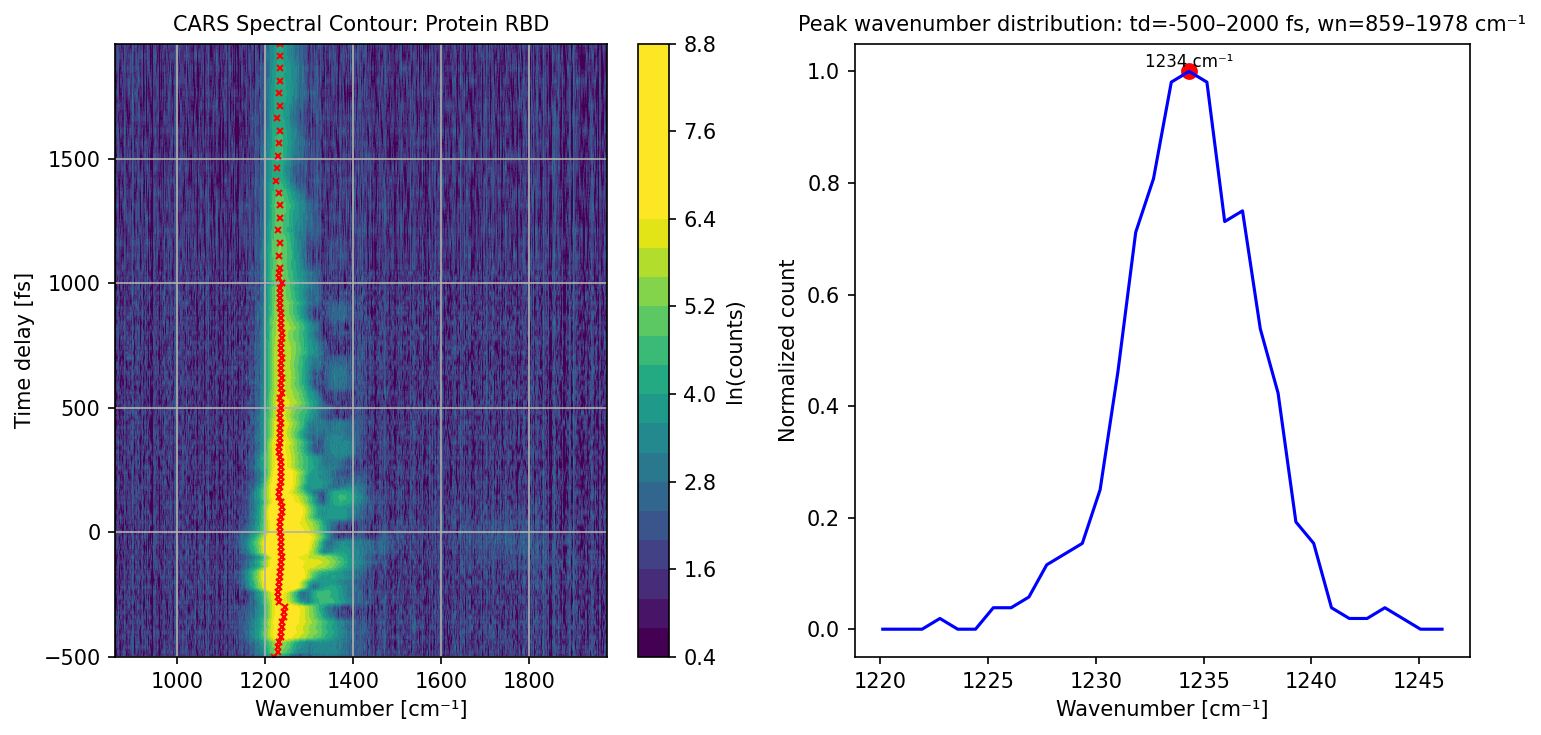

In [55]:
cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\May_28\RBD_15.dat" #all_cars_files_with_spectra[180] #
CARS = TdCARS.from_file(cars_file_path)
Z, P = CARS.get_spectra_contour(show_plot=True, no_of_peaks=1, td_lim=[-500, 2000])

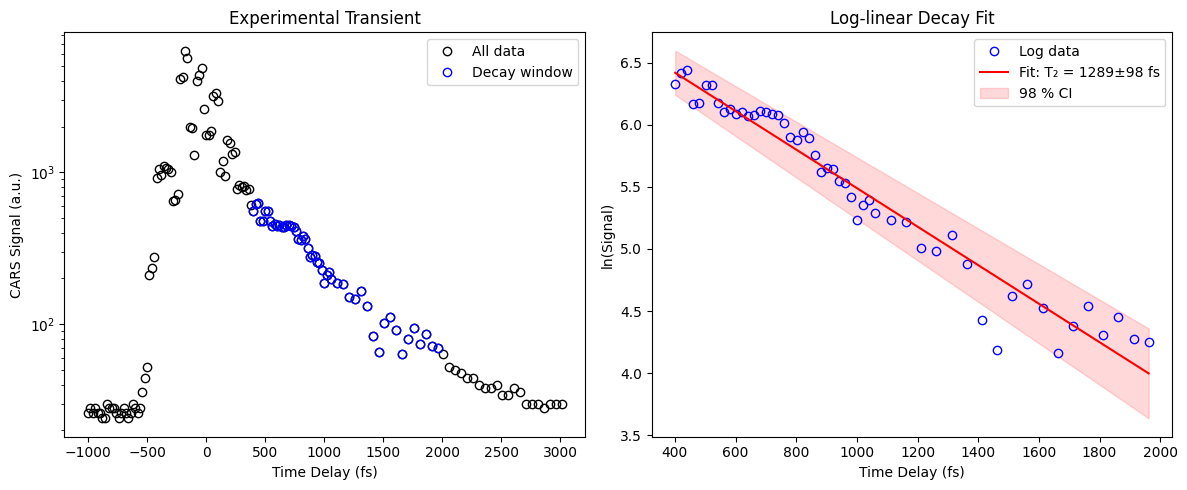

In [56]:
_ = CARS.get_T2(400,2000,show_plot=True)

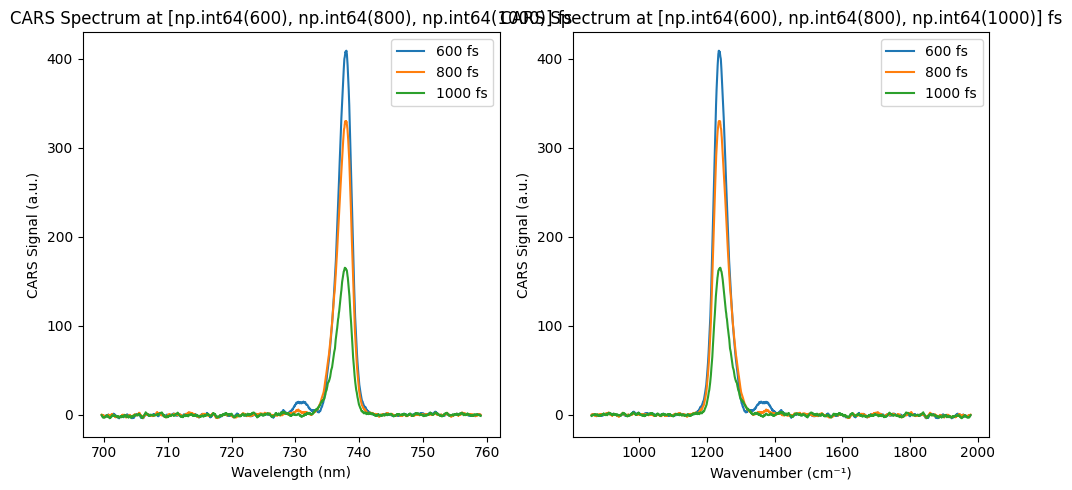

In [57]:
_ = CARS.plot_spectra_at_td([600, 800, 1000], show_plot=True, boxcar_window=20)

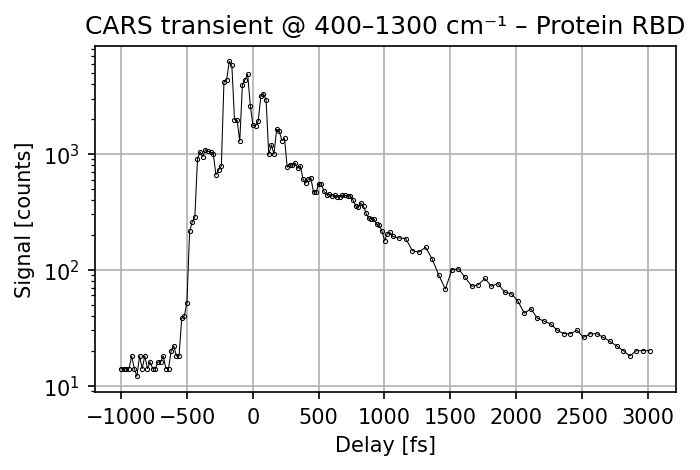

In [58]:
_ = CARS.get_transient_at_wn([400, 1300], show_plot=True)

In [59]:
CARS.notes_df

,0,1
0,DET,Syncerity CCD
1,SMP,Protein RBD
2,P3 (TiS),117
3,P1 (OPO1),230
4,P2 (OPO2),200
5,Polarizations,All parallel
6,Ti-Sa,812
7,OPO1,1018
8,OPO2,1124
9,MONO,730


[-105.46946271]


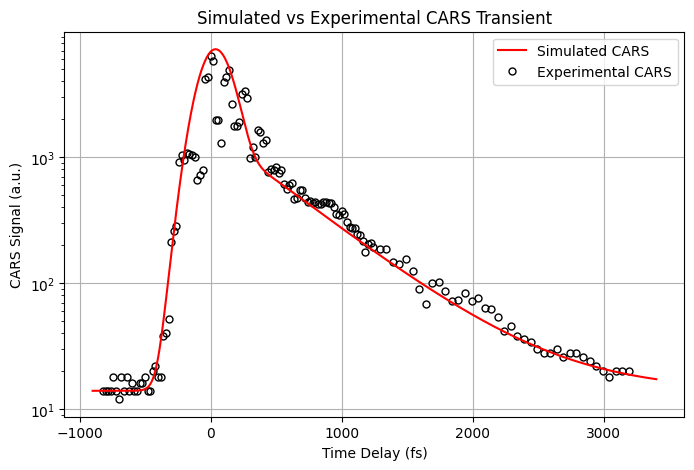

In [60]:
CARS.floor = 14
CARS.tmin, CARS.tmax = -2000, 4500
CARS.wl1, CARS.wl2 = 1018, 1150
CARS.T2 = np.array([1100])
CARS.nuR = np.array([1233])
CARS.A = np.array([5E22])
print(1E7*(1/CARS.wl1 - 1/CARS.wl2) - CARS.nuR)
td_fti, td_sig = CARS.CARS_simulation_FG(showPlot=False)
td_exp, sig_exp = CARS.get_transient_at_wn([400, 1300], show_plot=False)

plt.figure(figsize=(8, 5))
plt.plot(td_fti, td_sig, label="Simulated CARS", color="red", zorder=5)
plt.plot(td_exp-td_exp[sig_exp==np.max(sig_exp)][0], sig_exp[sig_exp>0], 'ko', mfc = 'none', ms = 5, label="Experimental CARS")
plt.yscale('log')
plt.xlabel("Time Delay (fs)")
plt.ylabel("CARS Signal (a.u.)")
plt.title("Simulated vs Experimental CARS Transient")
plt.legend()
plt.grid()

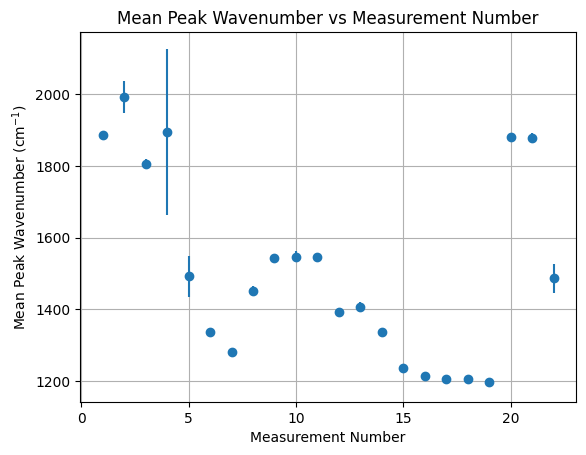

In [61]:
wn_arr = []
wn_std_arr = []
res_td_min, res_td_max = 800, 1200

for i in range(22):
    cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\May_28\RBD_{}.dat".format(i+1)
    CARS = TdCARS.from_file(cars_file_path)

    # Index of maximum pixel in each row (time step)
    peak_col = np.argmax(CARS.spectra_sc_full[(CARS.td_arr >= res_td_min) & (CARS.td_arr <= res_td_max), :], axis=1)
    peak_wn = CARS.wn_as[peak_col]
    wn_arr.append(np.mean(peak_wn))
    wn_std_arr.append(np.std(peak_wn, ddof=1))

plt.errorbar(range(1, 23), wn_arr, yerr=wn_std_arr, fmt='o')
plt.xlabel('Measurement Number')
plt.ylabel('Mean Peak Wavenumber (cm$^{-1}$)')
plt.title('Mean Peak Wavenumber vs Measurement Number')
plt.grid()
plt.show()